In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
from pathlib import Path
import os
from os.path import join
import sys

# Find KPIHub root (directory containing lib/tables), then import lib.* as a package.
_here = Path.cwd().resolve()
_root = next((p for p in [_here, *list(_here.parents)[:12]] if (p / "lib" / "tables").is_dir()), None)
if _root is None:
    raise FileNotFoundError(
        f"Could not find KPIHub root (folder containing lib/tables). cwd={Path.cwd()!r}"
    )
sys.path.insert(0, str(_root))
os.chdir(_root)

from locallib.picarrodb import *
from locallib.slack import *
from locallib.etl import Loggers
from locallib.pandas import *
from locallib.box import *

from lib.tables.IngesterTables import *
from lib.handlers.CustomerHandler import *
from lib.config import *
from lib.KPIHubConnection import *
from lib.query.bank import *

from datetime import date
from datetime import timedelta

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [ ]:
data = Query(query = f"SELECT * FROM KPI_SurveySummary").execute(KPIHub_Conn)
data = 
duplicate_reportids = data[data.duplicated(subset="SurveyId", keep=False)]
if not duplicate_reportids.empty:
    print("Duplicate ReportIds found:")
    #display(duplicate_reportids)
else:
    print("No duplicate ReportIds found in the selected date range.")
# Find two reports that have exactly the same set of surveys (SurveyIds)

# Create a mapping from ReportId to the set of SurveyIds for each Report
report_survey_sets = (
    data.groupby('ReportId')['SurveyId']
    .agg(lambda x: set(x))
    .reset_index()
)

# Find duplicates by the sets of SurveyIds: group by the set itself
report_survey_sets['SurveySetStr'] = report_survey_sets['SurveyId'].apply(lambda s: ','.join(sorted(s)))
duplicate_groups = report_survey_sets.groupby('SurveySetStr').filter(lambda x: len(x) > 1)

if not duplicate_groups.empty:
    print("Reports with identical sets of surveys (showing pairs):")
    # If there are more than 2 reports in a group, just show the first pair
    for _, group in duplicate_groups.groupby('SurveySetStr'):
        if len(group) > 1:
            reports = group['ReportId'].tolist()
            survey_ids = list(group.iloc[0]['SurveyId'])
            print(f"Report IDs with identical surveys: {reports[:2]}")
            print(f"Survey IDs set: {survey_ids}")
            break  # only print the first pair found
else:
    print("No reports with exactly identical sets of surveys found.")


Duplicate ReportIds found:
Reports with identical sets of surveys (showing pairs):
Report IDs with identical surveys: ['66529AE9-14A7-7991-5895-3A234F1C5000', 'AF403B20-F657-DEC9-7100-3A234F194FCC']
Survey IDs set: ['1498AD14-AF4A-BDB6-CDBF-3A23446B9DC2', 'F2E1A8B5-2482-976A-DB89-3A234990C638']


In [54]:
# Fix: Select data for ReportIds in the 'reports' list (not using elementwise comparison)
data[data['SurveyId'].isin(survey_ids)][['ReportId','SurveyId','SegmentWeight','SurveyDurationMinutes','SurveyRawDurationMinutes']]

,ReportId,SurveyId,SegmentWeight,SurveyDurationMinutes,SurveyRawDurationMinutes
112,AF403B20-F657-DEC9-7100-3A234F194FCC,1498AD14-AF4A-BDB6-CDBF-3A23446B9DC2,0.482927,148.766133,308.051083
113,66529AE9-14A7-7991-5895-3A234F1C5000,1498AD14-AF4A-BDB6-CDBF-3A23446B9DC2,0.453659,139.750004,308.051083
114,AF403B20-F657-DEC9-7100-3A234F194FCC,F2E1A8B5-2482-976A-DB89-3A234990C638,0.017778,5.459288,307.084967
115,66529AE9-14A7-7991-5895-3A234F1C5000,F2E1A8B5-2482-976A-DB89-3A234990C638,0.244444,75.065214,307.084967
116,E0020480-ED04-0CBD-88C1-3A234FC15DAE,F2E1A8B5-2482-976A-DB89-3A234990C638,0.635556,195.169557,307.084967
117,11EC67B2-373C-6B7F-498F-3A234FC24D0E,F2E1A8B5-2482-976A-DB89-3A234990C638,0.140000,42.991895,307.084967


In [16]:
report_ids = data[data['ReportId'].duplicated(keep=False)][['ReportId']]
report_ids.db.set_query(query = 'SELECT ReportId AS ReportId, ReportArea as ReportArea FROM KPI_ReportSummary WHERE ReportId IN (SELECT ReportId FROM temp_report_ids)')
ra = report_ids.db.execute(KPIHub_Conn, source_col="ReportId", temp_table_name="temp_report_ids")
ra

,ReportId,ReportArea
0,02AC72E8-F437-0AB3-D27E-3A23312DE315,MULTIPOLYGON (((20.920934600944225 49.97299907...
1,03F851A5-0232-5486-A7D2-3A20A4FD8050,MULTIPOLYGON (((20.268633328896676 50.14191663...
2,0B251056-7EA9-5E16-7C78-3A22E3FC5F82,MULTIPOLYGON (((20.145963506624547 50.01517826...
3,0D17B61C-0F61-8BF1-E5F3-3A20323A937F,MULTIPOLYGON (((20.036200407135592 50.06542694...
4,1289929A-230C-A37C-C990-3A1FEF76DAF6,MULTIPOLYGON (((19.445078591074591 50.18984725...
...,...,...
96,F893BB37-0071-1F73-C539-3A236844F414,MULTIPOLYGON (((20.25248348719645 50.049546352...
97,FB750F28-61B6-7D91-4881-3A20E4FA7A5F,MULTIPOLYGON (((20.097615880095539 50.09348834...
98,FD040581-EEB1-1CAF-7B49-3A21320B4141,MULTIPOLYGON (((19.883476033712164 49.55695521...
99,FE72F04B-8DB4-6F1E-BB50-3A1F2113AB99,MULTIPOLYGON (((19.955833049532767 50.07981170...


In [4]:
query = (
    "SELECT SurveyId, FieldOfView.STAsText() AS Breadcrumb "
    "FROM SurveyResult "
    "WHERE SurveyId IN (SELECT SurveyId FROM #TempSurvey)"
)
survey_ids = pd.DataFrame(data['SurveyId'].unique(), columns=["SurveyId"])
survey_ids.db.set_query(query_SurveyH3Aggregation(survey_table = "#TempSurvey"))
breadcrubs = survey_ids.db.execute(EU1_Conn, source_col="SurveyId", temp_table_name="#TempSurvey")


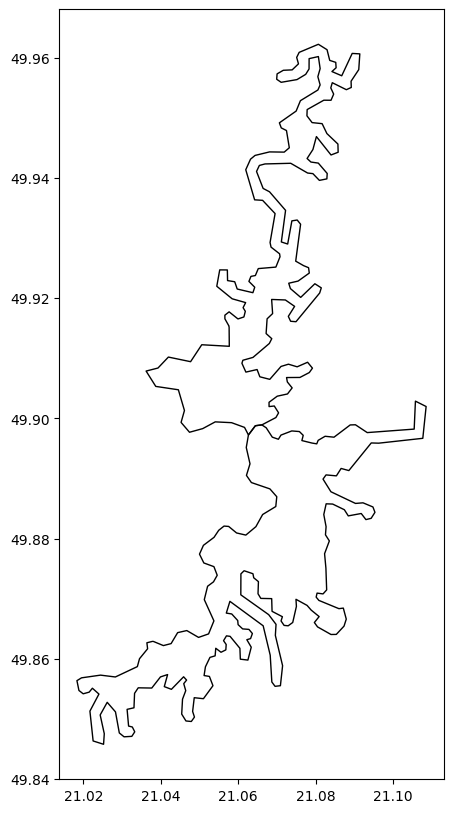

In [47]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

fig, ax = plt.subplots(figsize=(10, 10))
for report in reports:
    # Get the WKT string for the ReportArea for this report
    wkt_str = ra.loc[ra['ReportId'] == report, 'ReportArea'].iloc[0]
    # Convert WKT to a geometry object
    geom = wkt.loads(wkt_str)
    # Create a GeoDataFrame
    report_area_gdf = gpd.GeoDataFrame({'geometry': [geom]}, crs="EPSG:4326")
    # Plot
    report_area_gdf.plot(ax=ax, edgecolor='black', facecolor='none')



